In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
epsilon = 0.01
data = pd.read_csv(f"vectorize_experimentadult_ExpGrad_08-12-2025_14-26-19/results_{epsilon}.csv")

In [12]:
def max_differences(load_path):
    epsilons = np.linspace(0.01,0.1,11)
    for i,eps in enumerate(epsilons):
        eps = round(eps,3)

        if not os.path.exists(f"{load_path}/results_{eps}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{eps}.csv")[["entropy_nodtype","entropy_float16","entropy_float32","entropy_float64","entropy_longdouble"]]
        data["row_max_diff"] = data.max(axis=1) - data.min(axis=1)
        max_diff = data["row_max_diff"].max(axis=0)
        max_diff_row = data["row_max_diff"].argmax(axis=0)
        print(f"Eps: {eps} | Max difference: {max_diff} | Row: {max_diff_row}")


In [14]:
def plot_avg_entropy_expgrad(model,dataset,load_path,save_path):
    fig, ax = plt.subplots(1,1,figsize=(20,10))
    entr1_mean = []
    entr1_std = []
    entr2_mean = []
    entr2_std = []
    entr3_mean = []
    entr3_std = []
    entr4_mean = []
    entr4_std = []
    entr5_mean = []
    entr5_std = []

    epsilons = np.linspace(0.01,0.1,11)
    for i,eps in enumerate(epsilons):
        eps = round(eps,3)

        if not os.path.exists(f"{load_path}/results_{eps}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{eps}.csv")
        entr1 = data["entropy_nodtype"].to_numpy()
        entr2= data["entropy_float16"].to_numpy()
        entr3= data["entropy_float32"].to_numpy()
        entr4= data["entropy_float64"].to_numpy()
        entr5= data["entropy_longdouble"].to_numpy()
        S = data["S"].to_numpy()

        entr1_mean.append(np.mean(entr1))
        entr1_std.append(np.std(entr1))
        entr2_mean.append(np.mean(entr2))
        entr2_std.append(np.std(entr2))
        entr3_mean.append(np.mean(entr3))
        entr3_std.append(np.std(entr3))
        entr4_mean.append(np.mean(entr4))
        entr4_std.append(np.std(entr4))
        entr5_mean.append(np.mean(entr5))
        entr5_std.append(np.std(entr5))
    
    ax.errorbar(epsilons, entr1_mean, yerr=entr1_std,capsize=3, fmt="--o",label="no dtype")
    ax.errorbar(epsilons, entr2_mean, yerr=entr2_std,capsize=3, fmt="--o",label="f16")
    ax.errorbar(epsilons, entr3_mean, yerr=entr3_std,capsize=3, fmt="--o",label="f32")
    ax.errorbar(epsilons, entr4_mean, yerr=entr4_std,capsize=3, fmt="--o",label="f64")
    ax.errorbar(epsilons, entr5_mean, yerr=entr5_std,capsize=3, fmt="--o",label="longdouble")

    ax.set_title("All sens. groups")
    ax.set_xlabel("Gamma")
    ax.set_ylabel("Entropy")
    ax.set_ylim(-0.1,1.1)
    ax.legend()

    #plt.savefig(f"{save_path}/{dataset}_{model}_avg_entropy.pdf")

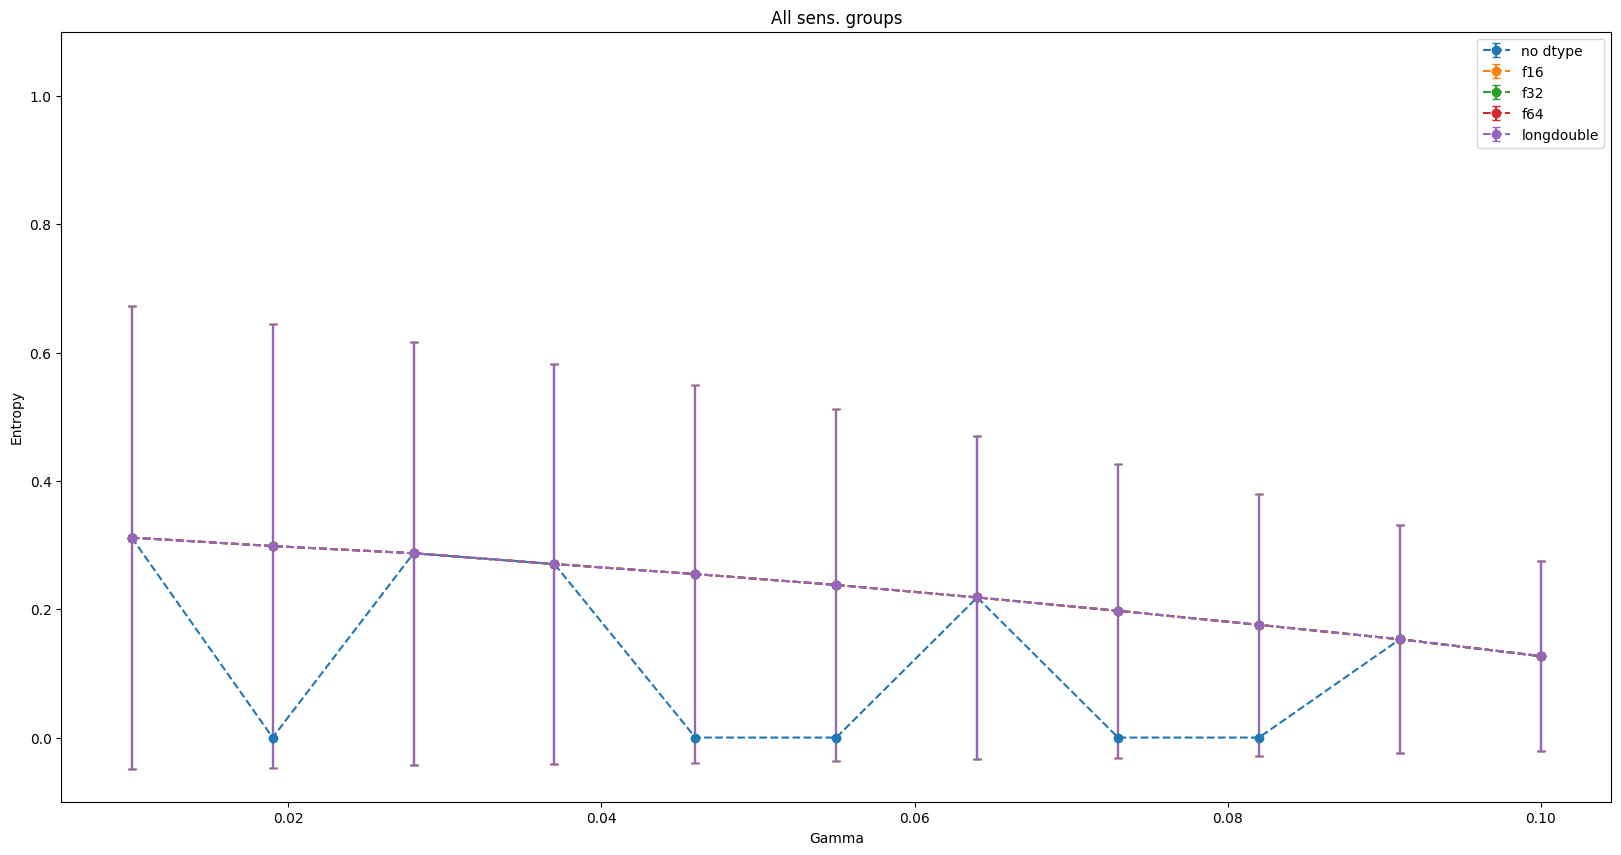

In [15]:
plot_avg_entropy_expgrad("ExpGrad","adult","vectorize_experimentadult_ExpGrad_08-12-2025_14-26-19",".")

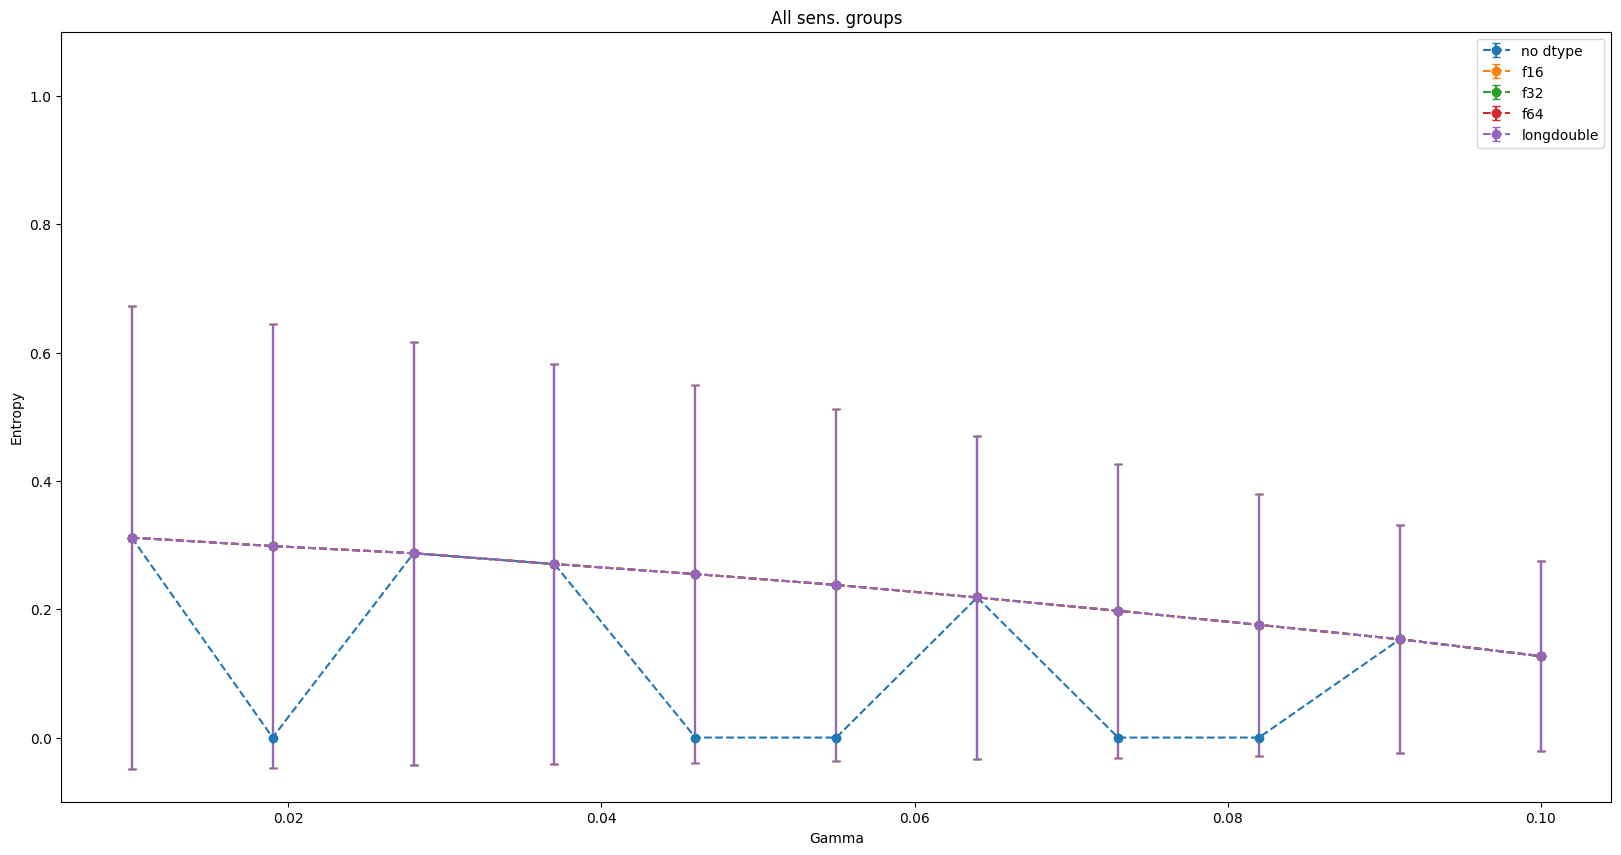

In [16]:
plot_avg_entropy_expgrad("ExpGrad","adult","vectorize_experimentadult_ExpGrad_09-12-2025_18-47-49",".")

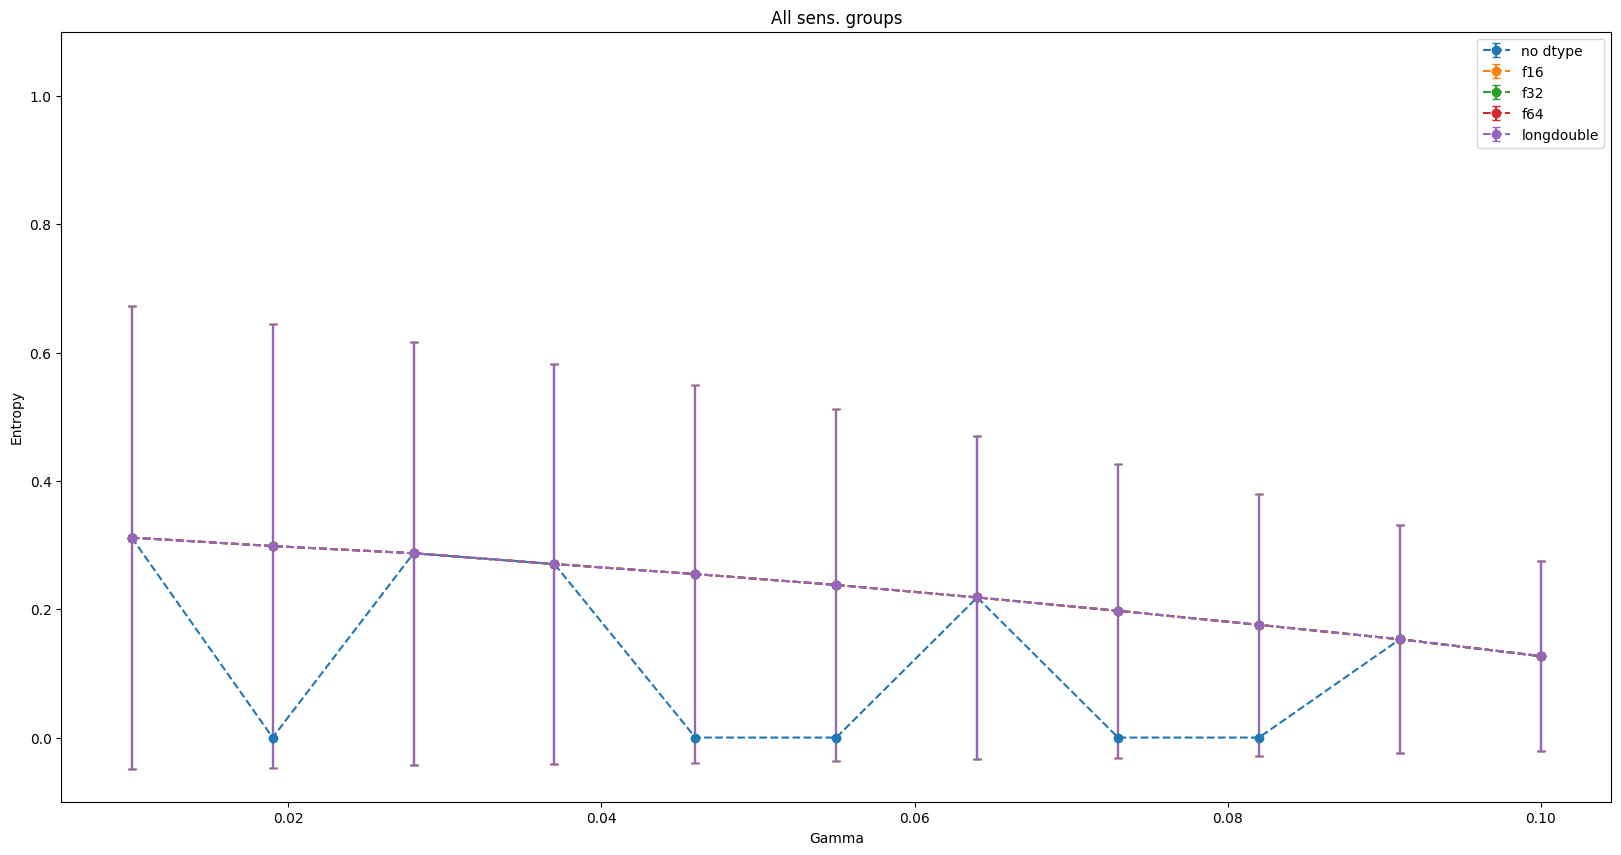

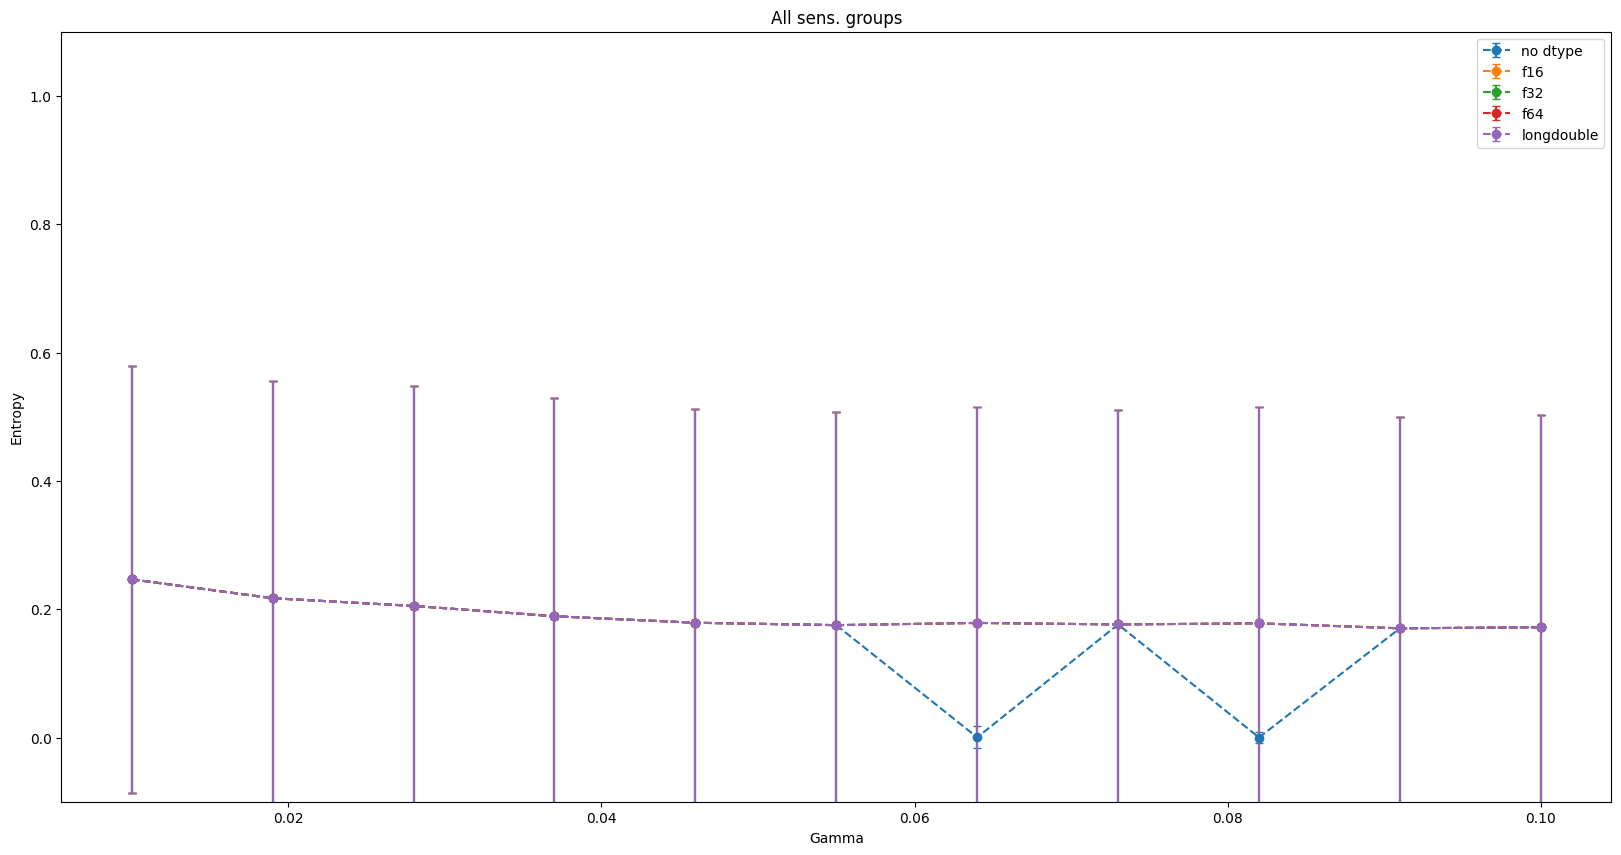

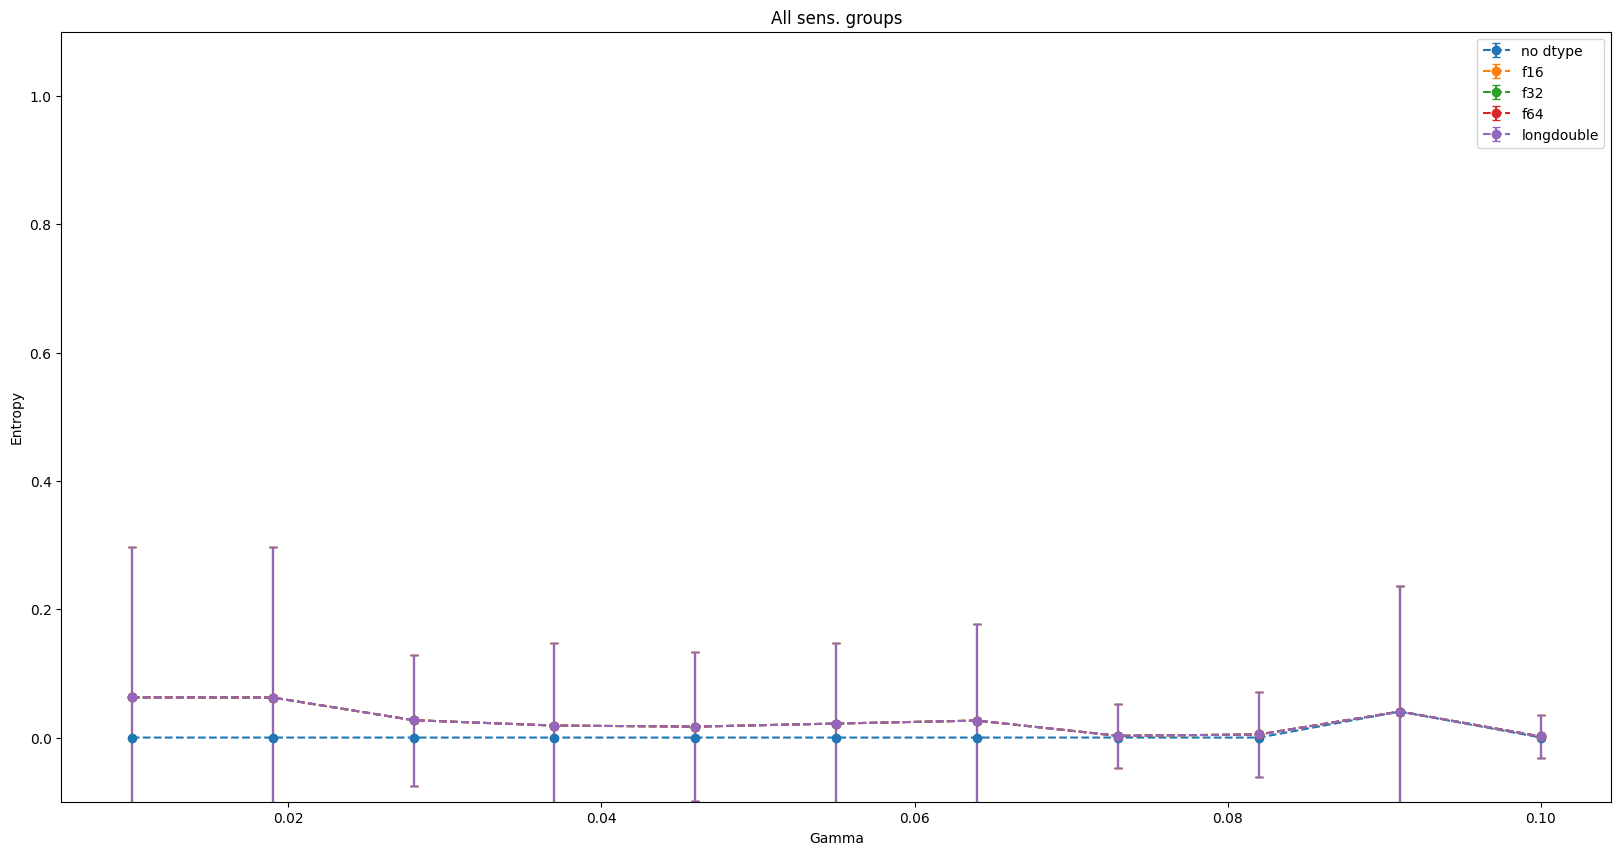

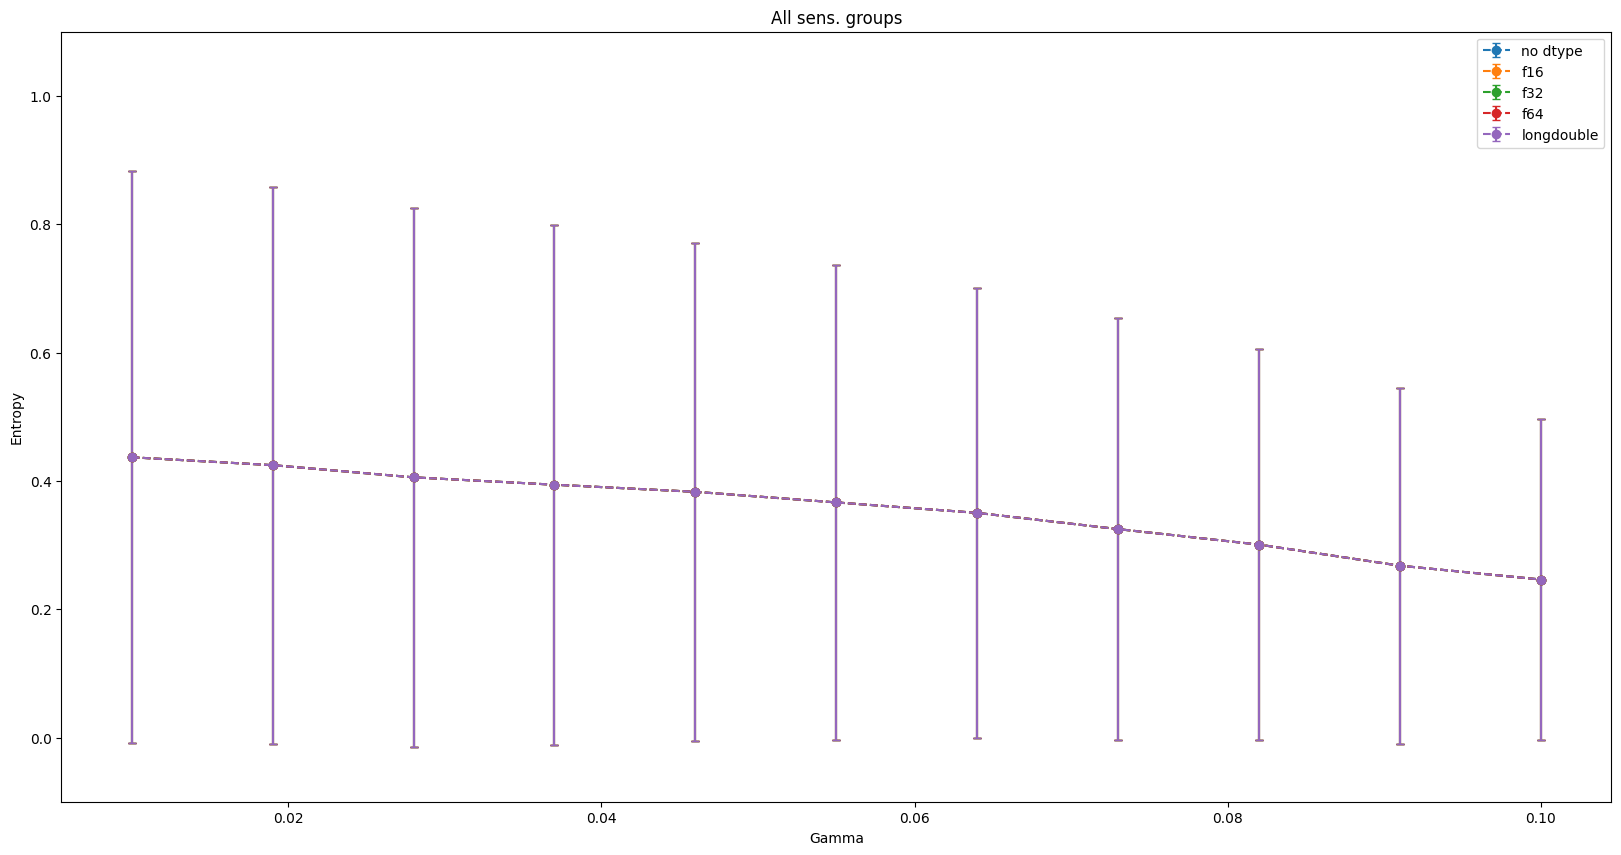

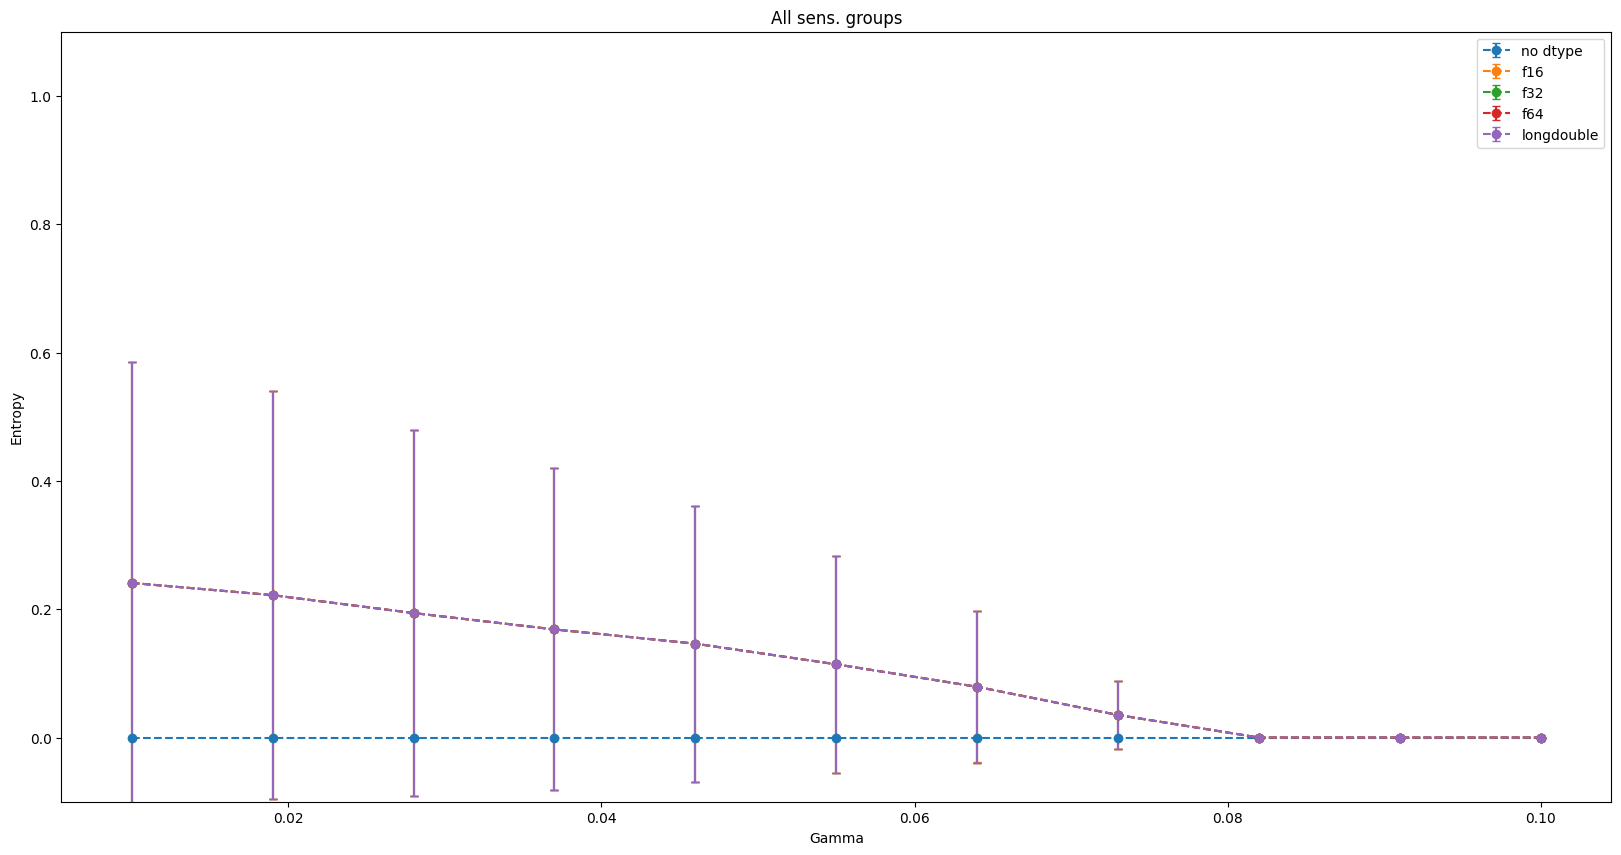

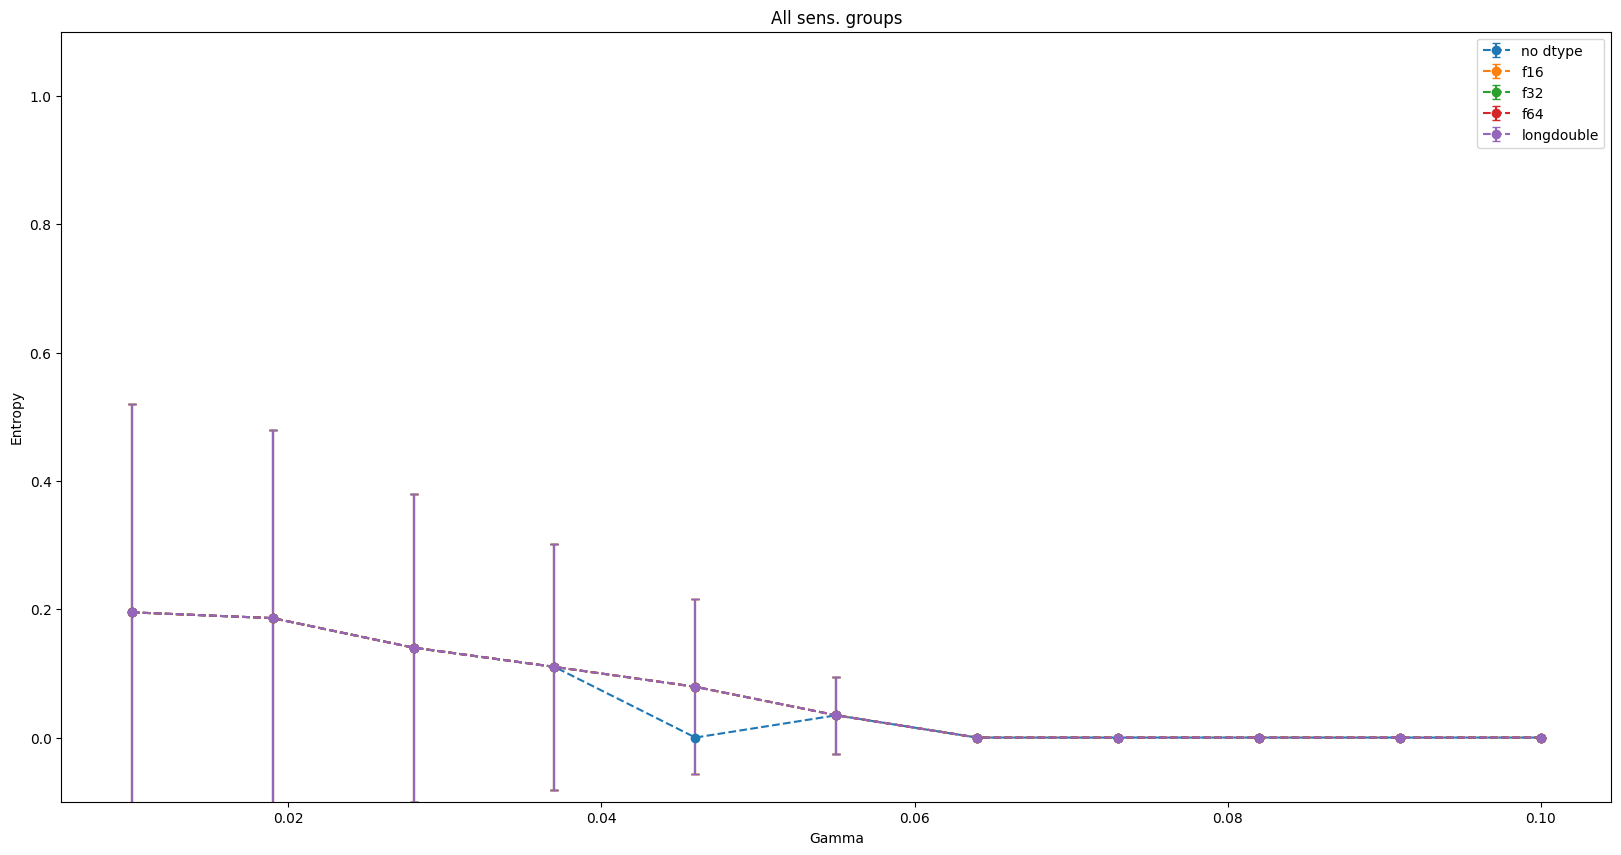

In [17]:
plot_avg_entropy_expgrad("ExpGrad","adult","results/vectorize_experimentadult_ExpGrad_11-12-2025_12-32-50",".")
plot_avg_entropy_expgrad("ExpGrad","banks","results/vectorize_experimentbanks_ExpGrad_11-12-2025_12-37-03",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results/vectorize_experimentcompas_ExpGrad_11-12-2025_12-36-44",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results/vectorize_experimentfolktables_AK_ExpGrad_11-12-2025_12-38-02",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results/vectorize_experimentfolktables_HI_ExpGrad_11-12-2025_12-38-21",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results/vectorize_experimentgerman_ExpGrad_11-12-2025_12-37-21",".")

In [13]:
max_differences("results/vectorize_experimentadult_ExpGrad_11-12-2025_12-32-50")
max_differences("results/vectorize_experimentbanks_ExpGrad_11-12-2025_12-37-03")
max_differences("results/vectorize_experimentcompas_ExpGrad_11-12-2025_12-36-44")
max_differences("results/vectorize_experimentfolktables_AK_ExpGrad_11-12-2025_12-38-02")
max_differences("results/vectorize_experimentfolktables_HI_ExpGrad_11-12-2025_12-38-21")
max_differences("results/vectorize_experimentgerman_ExpGrad_11-12-2025_12-37-21")

Eps: 0.01 | Max difference: 0.0003898602242521365 | Row: 151
Eps: 0.019 | Max difference: 0.785 | Row: 3355
Eps: 0.028 | Max difference: 0.0003898602242521365 | Row: 1879
Eps: 0.037 | Max difference: 0.00037485000000003765 | Row: 2600
Eps: 0.046 | Max difference: 0.689 | Row: 9113
Eps: 0.055 | Max difference: 0.6437935214851035 | Row: 5772
Eps: 0.064 | Max difference: 0.00032786000000006865 | Row: 409
Eps: 0.073 | Max difference: 0.552 | Row: 2383
Eps: 0.082 | Max difference: 0.5 | Row: 940
Eps: 0.091 | Max difference: 0.0001807172571564042 | Row: 328
Eps: 0.1 | Max difference: 0.00018071725715629317 | Row: 719
Eps: 0.01 | Max difference: 0.00042600000000003746 | Row: 1034
Eps: 0.019 | Max difference: 0.00042600000000003746 | Row: 162
Eps: 0.028 | Max difference: 0.00042600000000003746 | Row: 1043
Eps: 0.037 | Max difference: 0.00042600000000003746 | Row: 4422
Eps: 0.046 | Max difference: 0.00042600000000003746 | Row: 702
Eps: 0.055 | Max difference: 0.00042600000000003746 | Row: 694
E

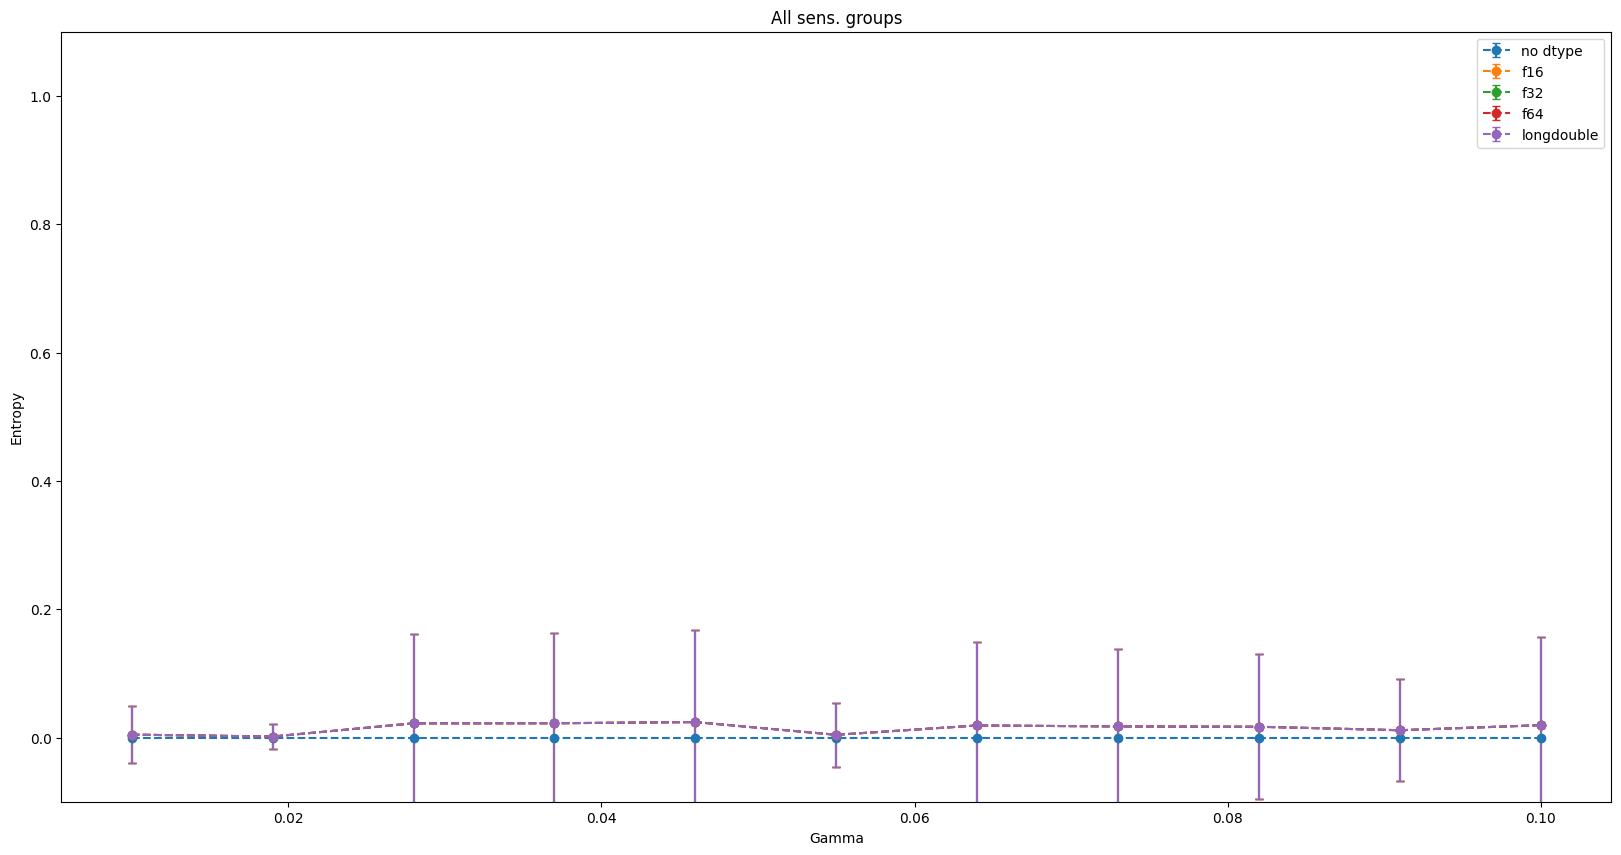

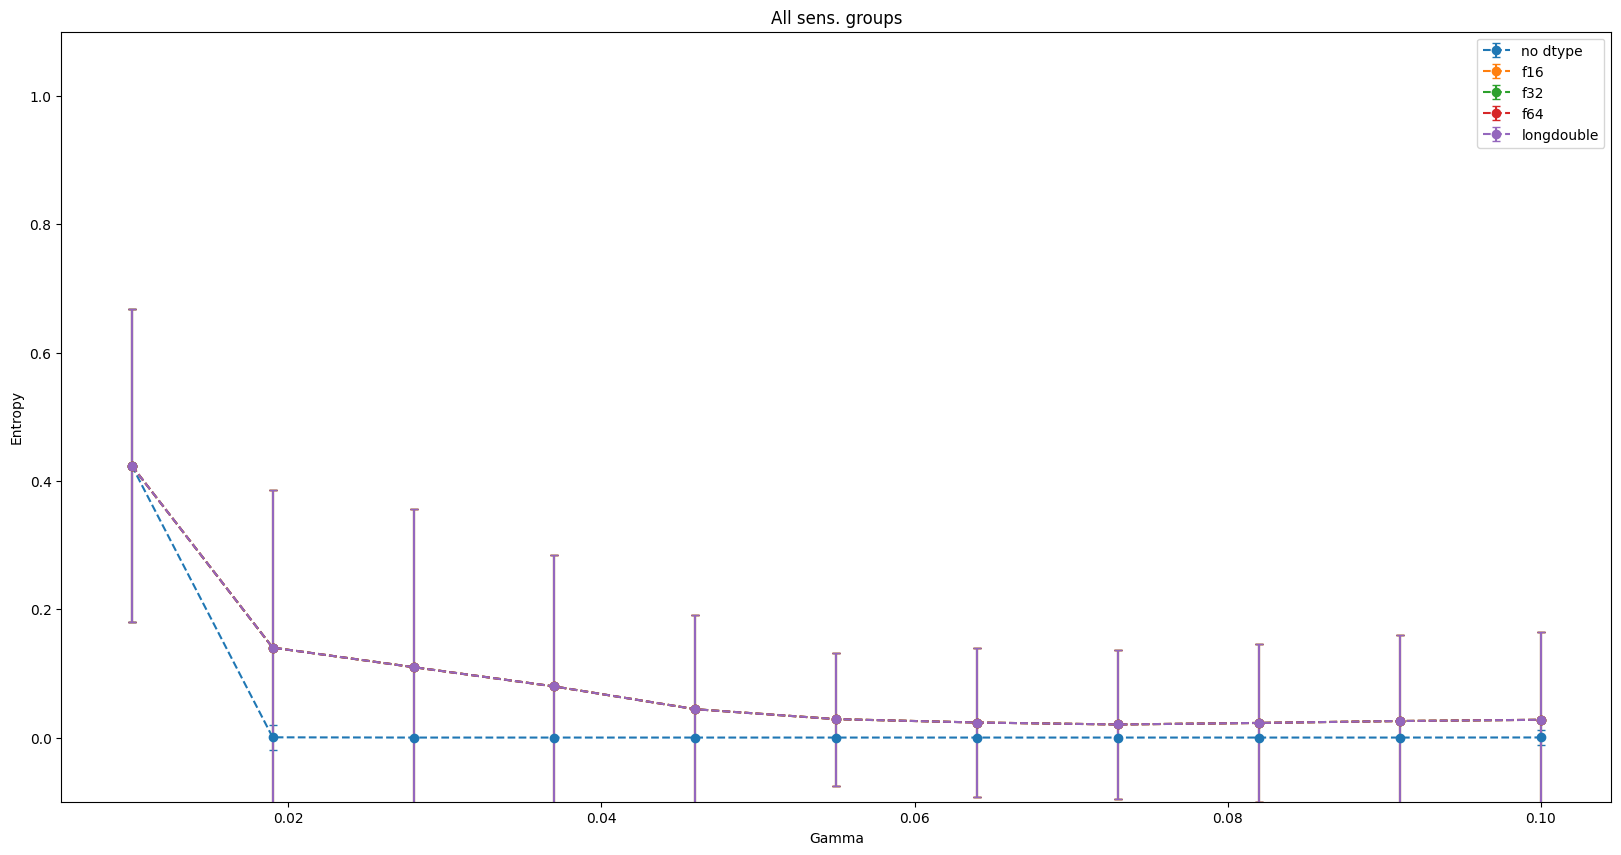

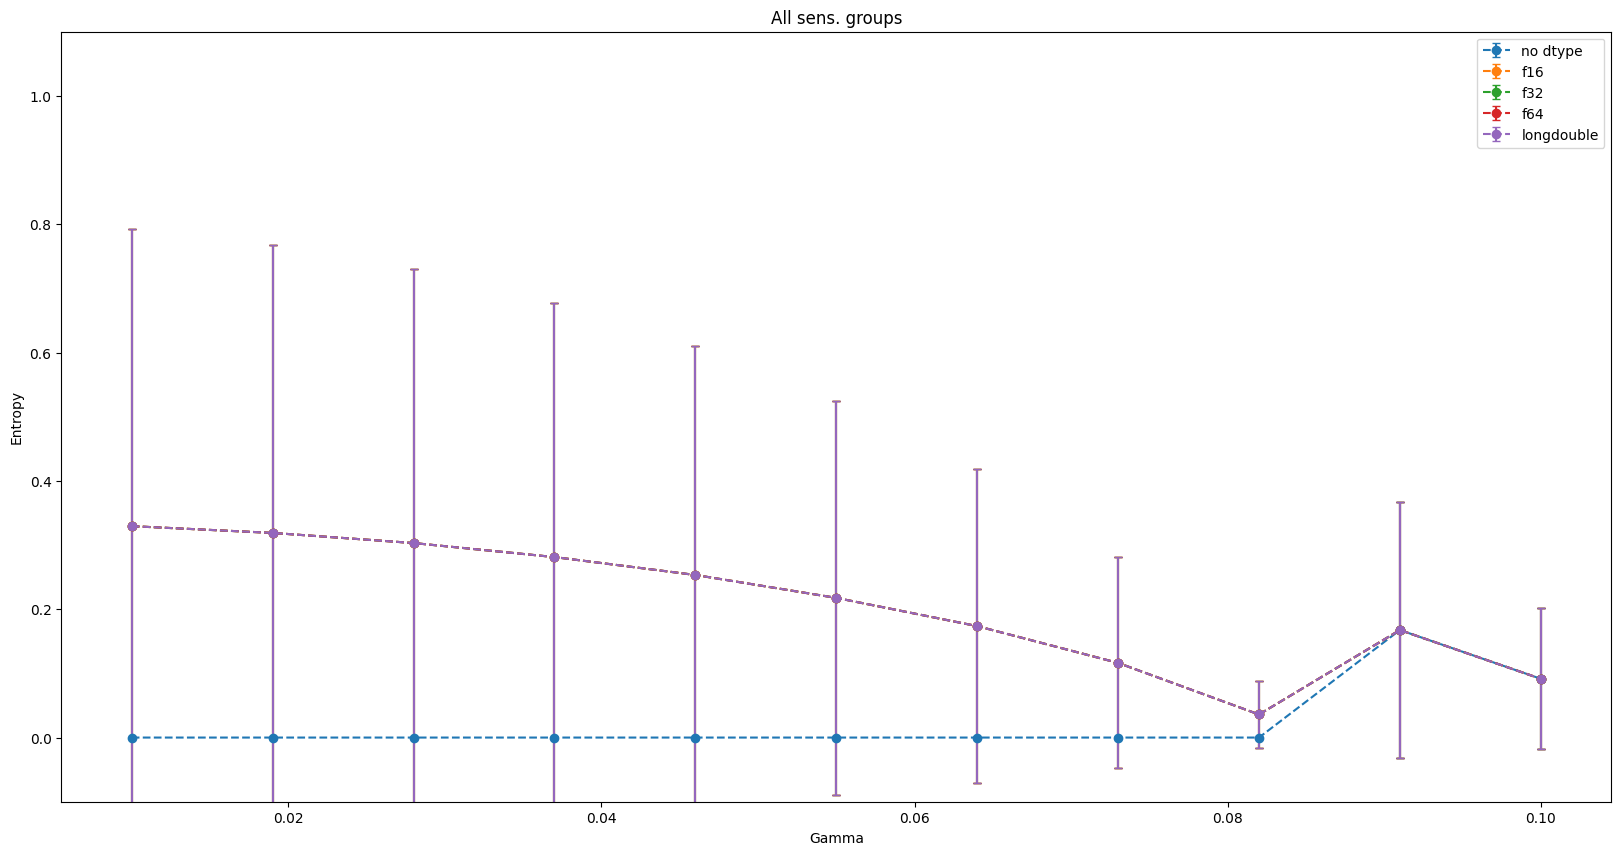

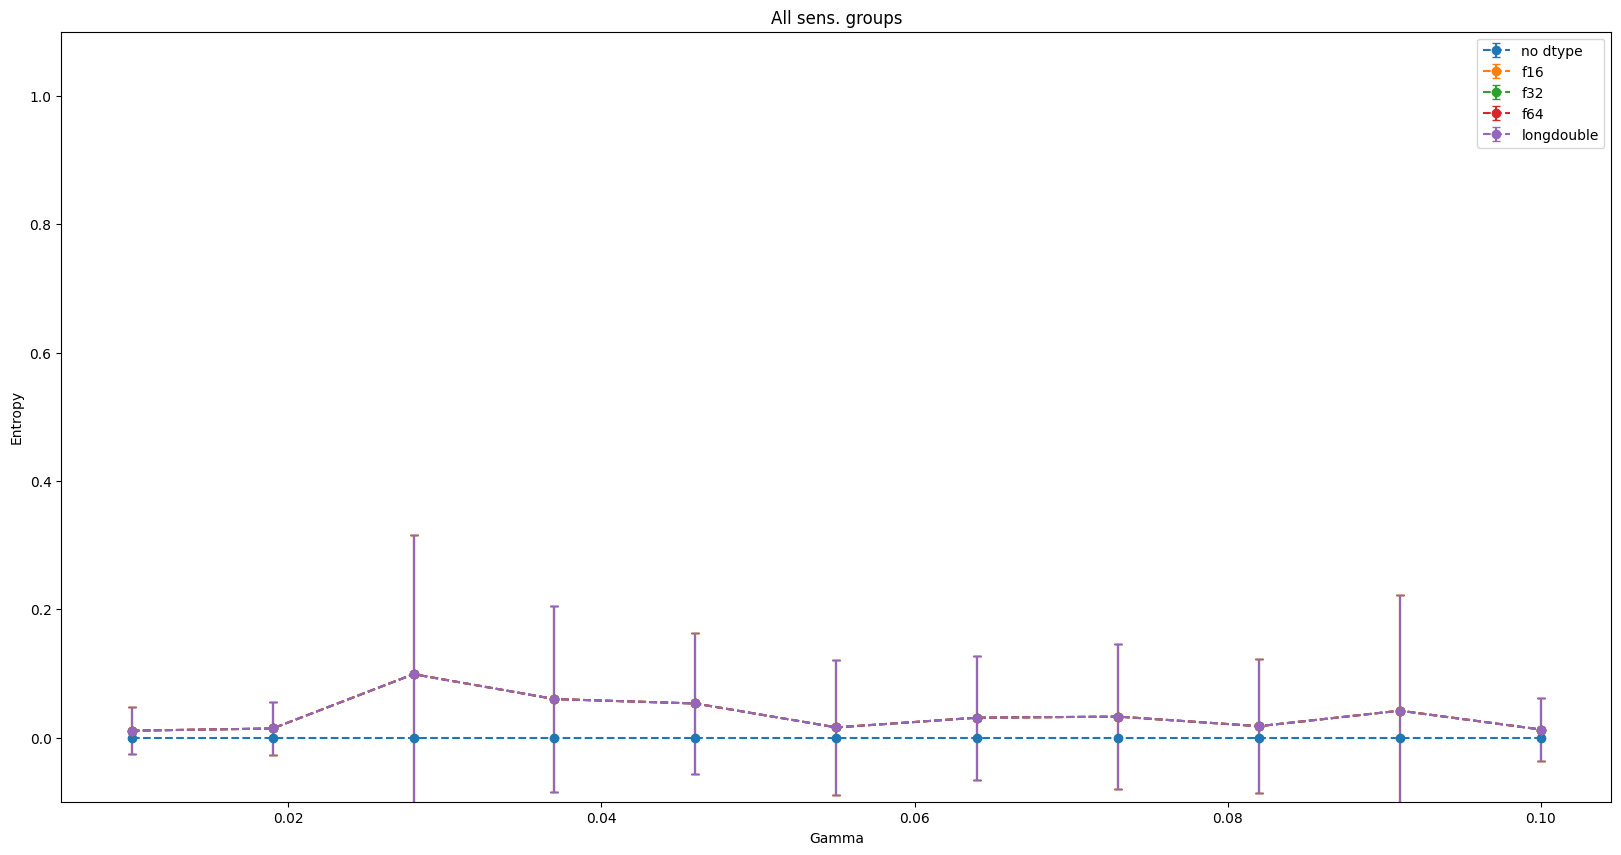

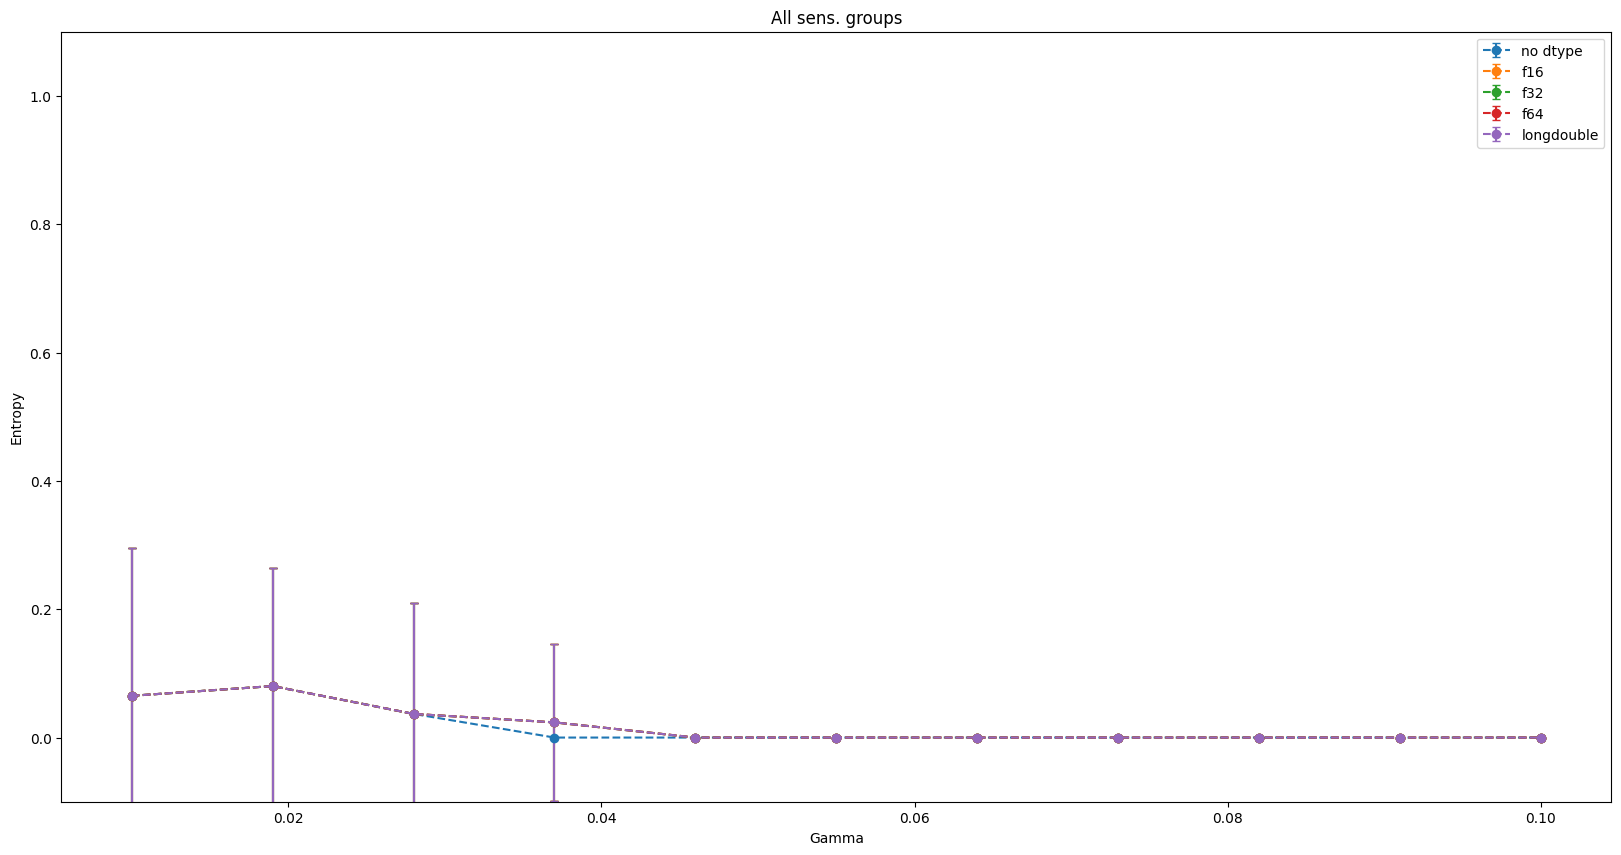

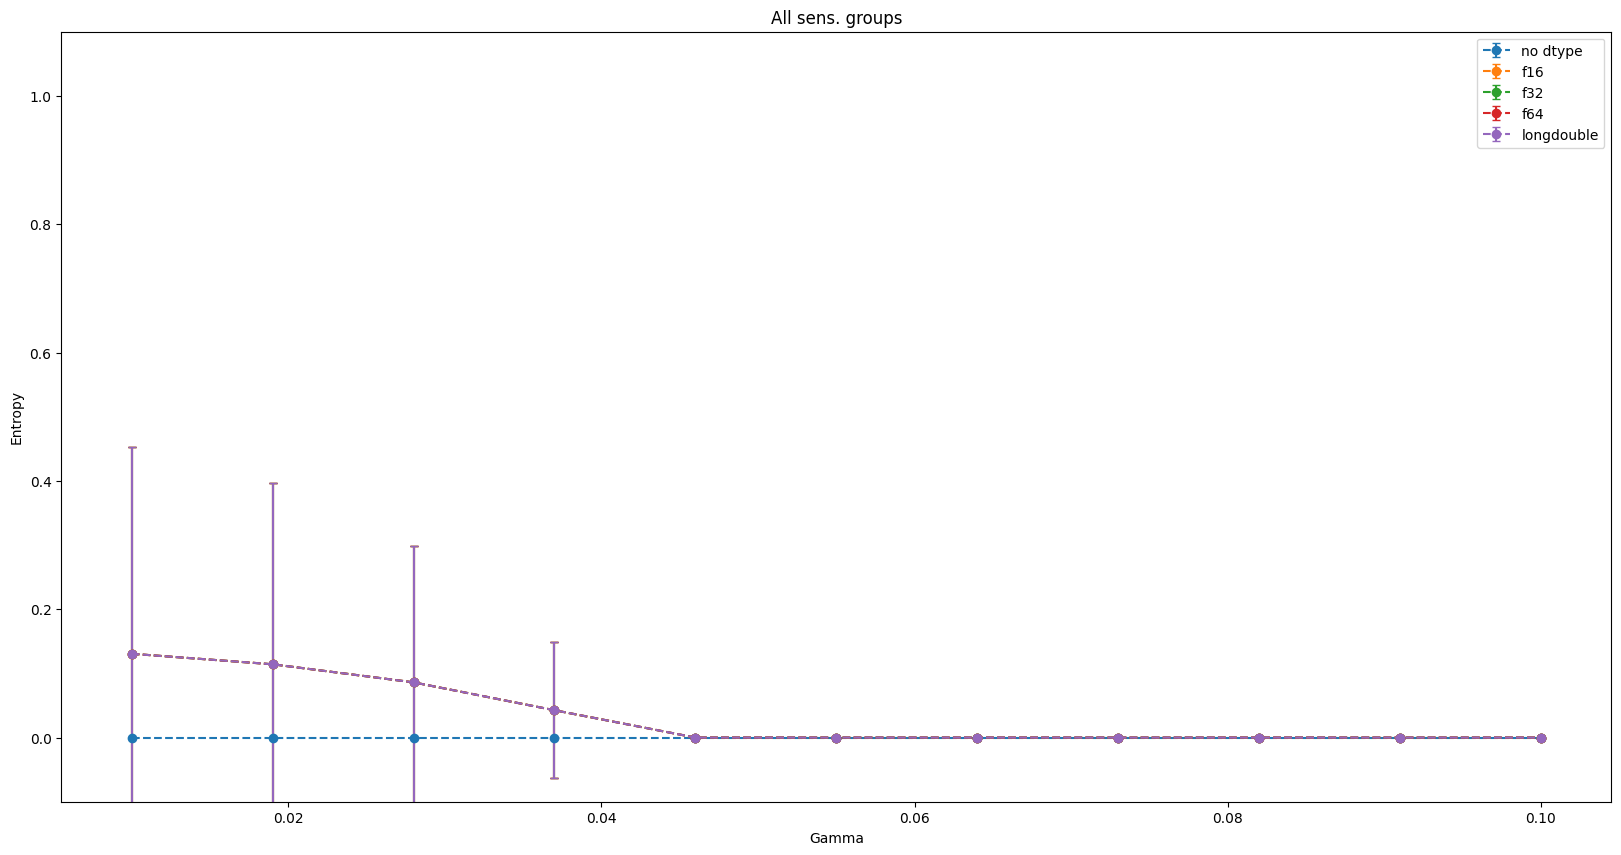

In [18]:
plot_avg_entropy_expgrad("ExpGrad","adult","results_logreg/vectorize_experimentadult_ExpGrad_11-12-2025_14-39-27",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results_logreg/vectorize_experimentbanks_ExpGrad_11-12-2025_14-38-38",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results_logreg/vectorize_experimentcompas_ExpGrad_11-12-2025_14-38-38",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results_logreg/vectorize_experimentfolktables_AK_ExpGrad_11-12-2025_14-38-45",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results_logreg/vectorize_experimentfolktables_HI_ExpGrad_11-12-2025_14-38-50",".")
plot_avg_entropy_expgrad("ExpGrad","adult","results_logreg/vectorize_experimentgerman_ExpGrad_11-12-2025_14-38-38",".")

In [11]:
max_differences("results_logreg/vectorize_experimentadult_ExpGrad_11-12-2025_14-39-27")
max_differences("results_logreg/vectorize_experimentbanks_ExpGrad_11-12-2025_14-38-38")
max_differences("results_logreg/vectorize_experimentcompas_ExpGrad_11-12-2025_14-38-38")
max_differences("results_logreg/vectorize_experimentfolktables_AK_ExpGrad_11-12-2025_14-38-45")
max_differences("results_logreg/vectorize_experimentfolktables_HI_ExpGrad_11-12-2025_14-38-50")
max_differences("results_logreg/vectorize_experimentgerman_ExpGrad_11-12-2025_14-38-38")

Eps: 0.01 | Max difference: 0.506
Eps: 0.019 | Max difference: 0.3154190889380809
Eps: 0.028 | Max difference: 0.9340681
Eps: 0.037 | Max difference: 0.9507
Eps: 0.046 | Max difference: 0.926
Eps: 0.055 | Max difference: 0.651
Eps: 0.064 | Max difference: 0.95661724
Eps: 0.073 | Max difference: 0.8955
Eps: 0.082 | Max difference: 0.8400260364931234
Eps: 0.091 | Max difference: 0.6390728
Eps: 0.1 | Max difference: 1.0
Eps: 0.01 | Max difference: 0.00042600000000003746
Eps: 0.019 | Max difference: 1.0
Eps: 0.028 | Max difference: 1.0
Eps: 0.037 | Max difference: 0.9507
Eps: 0.046 | Max difference: 0.78320444
Eps: 0.055 | Max difference: 0.8145
Eps: 0.064 | Max difference: 0.7583373241205442
Eps: 0.073 | Max difference: 0.9907
Eps: 0.082 | Max difference: 0.9976
Eps: 0.091 | Max difference: 1.0
Eps: 0.1 | Max difference: 1.0
Eps: 0.01 | Max difference: 0.9976
Eps: 0.019 | Max difference: 0.9770226
Eps: 0.028 | Max difference: 0.946
Eps: 0.037 | Max difference: 0.8861256474645223
Eps: 0.04

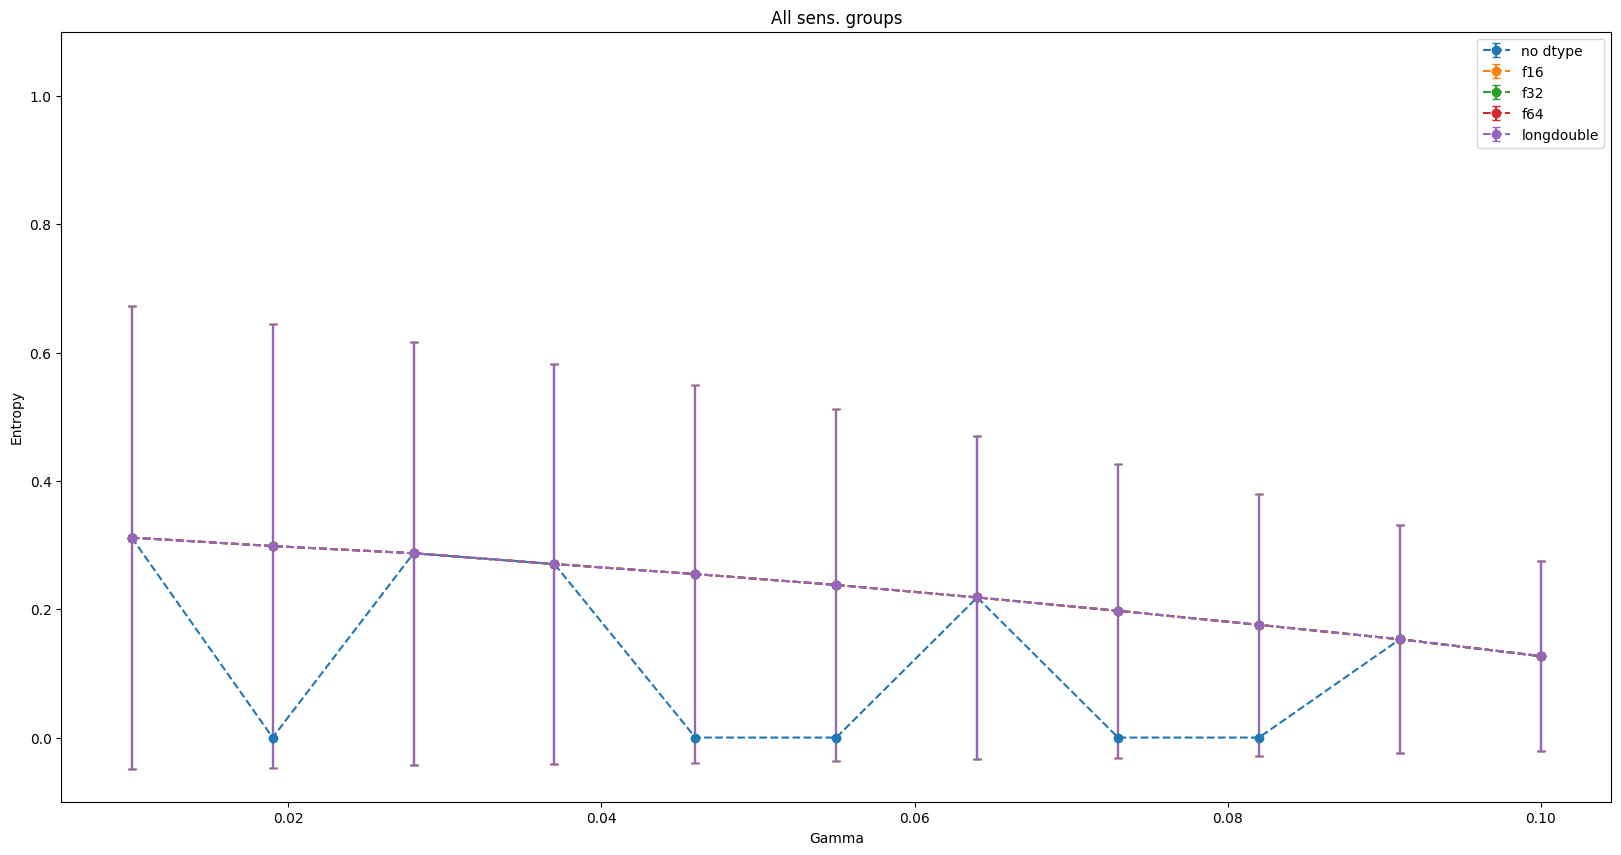

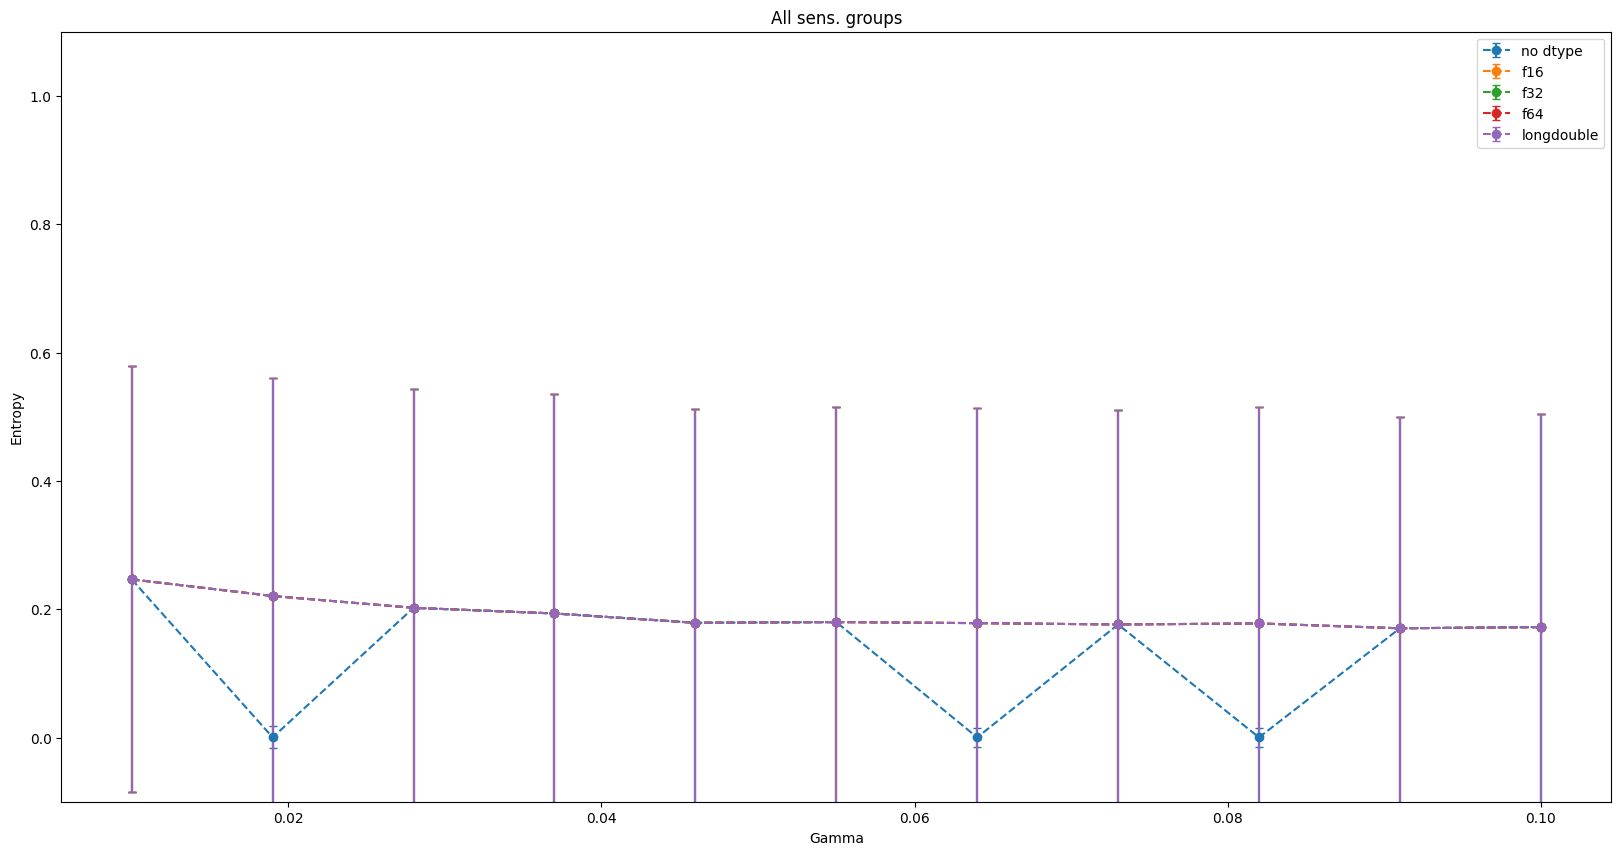

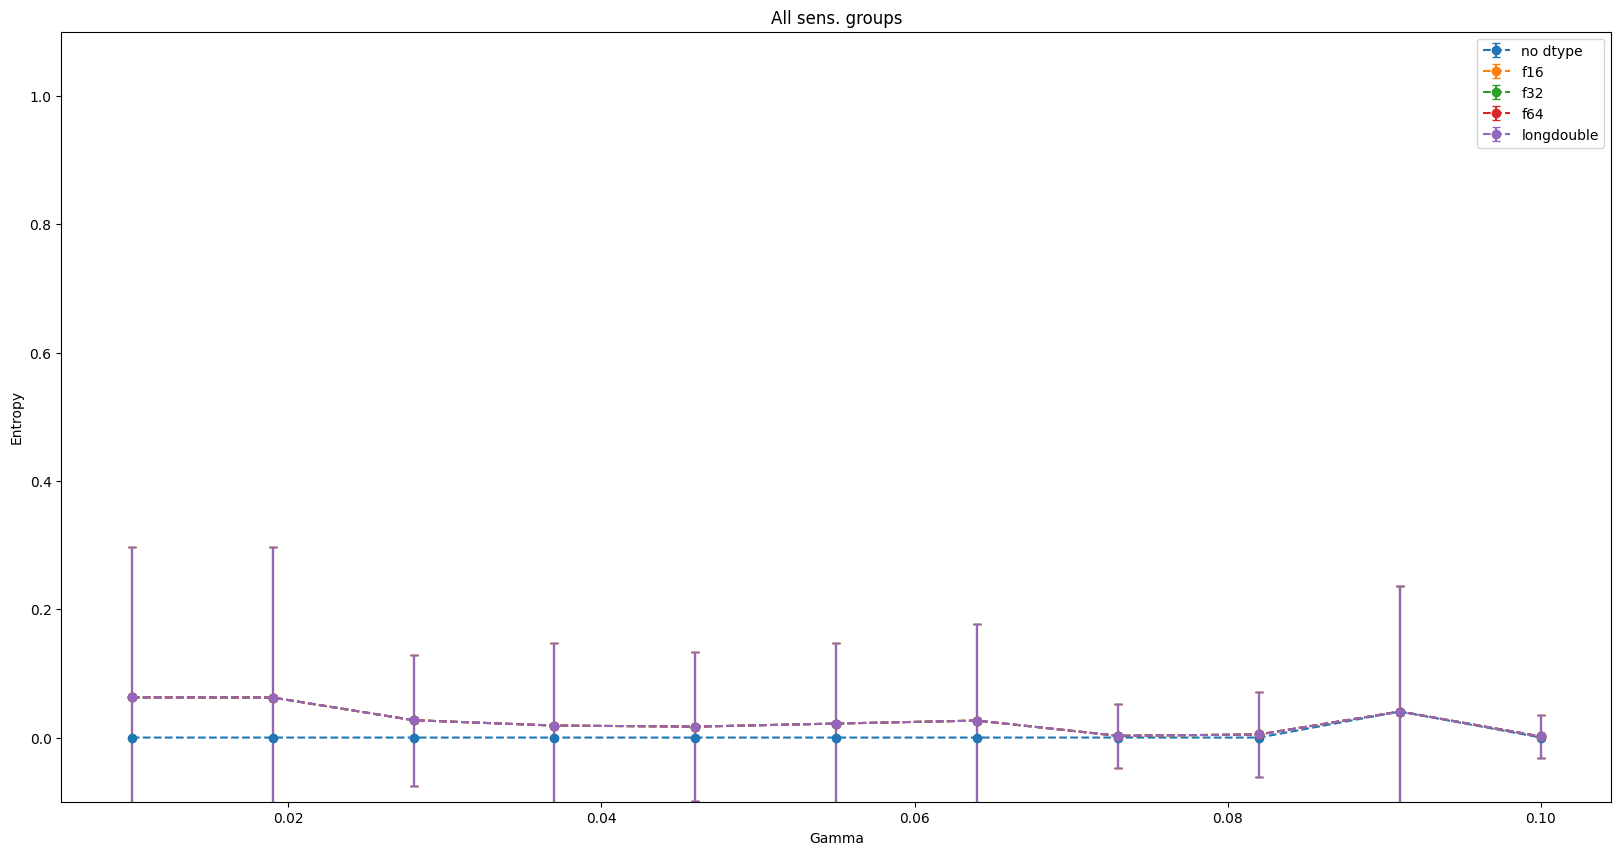

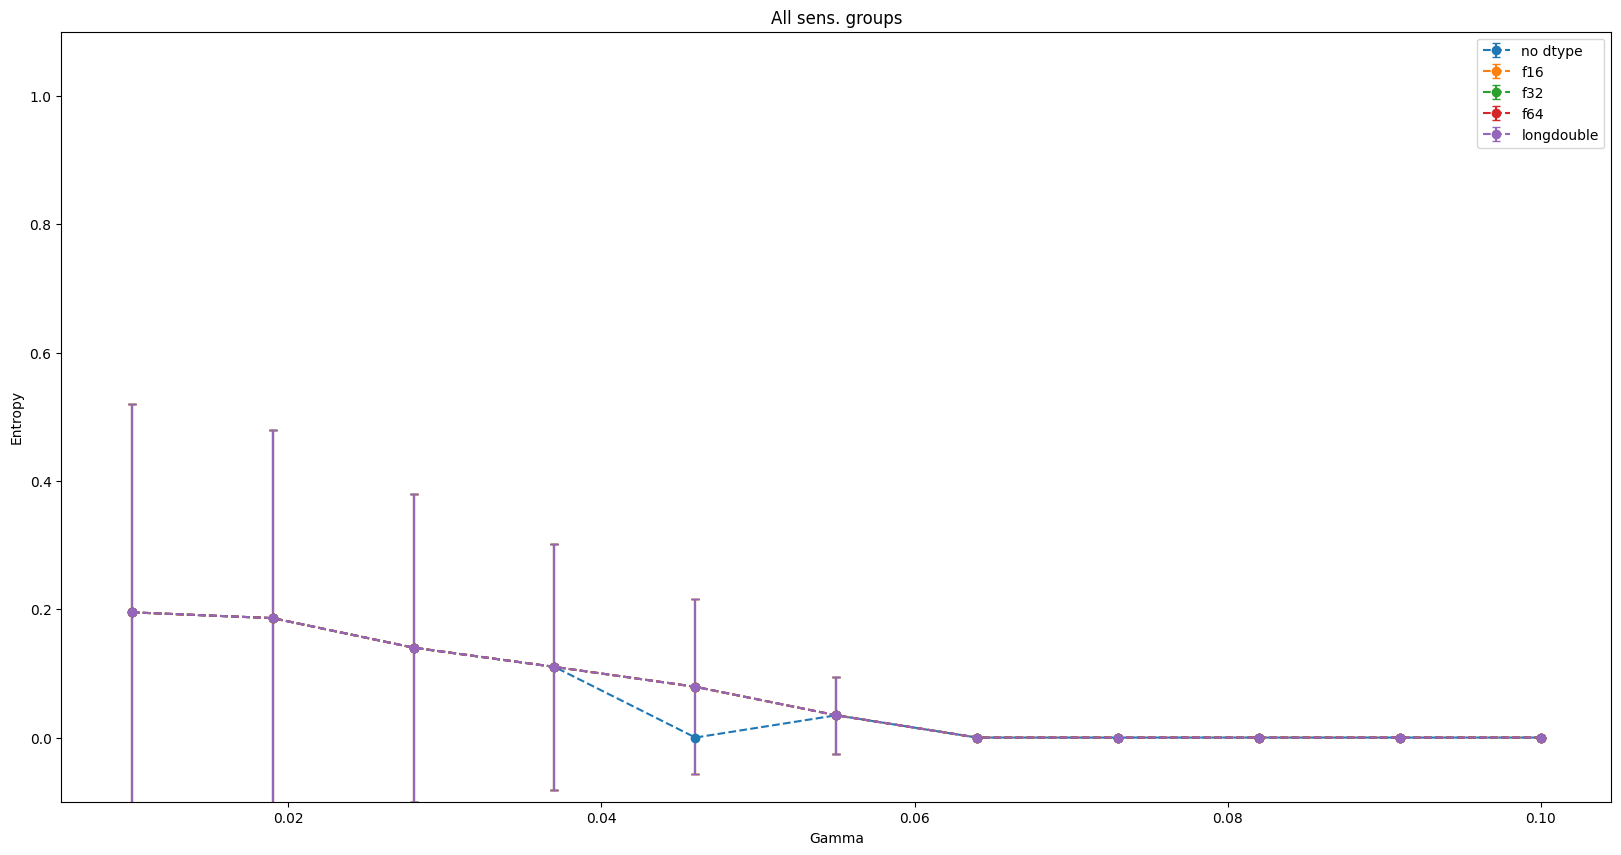

In [19]:
plot_avg_entropy_expgrad("ExpGrad","adult","../results/results_16-12-2025/vectorize_experimentadult_ExpGrad_16-12-2025_16-09-21",".")
plot_avg_entropy_expgrad("ExpGrad","banks","../results/results_16-12-2025/vectorize_experimentbanks_ExpGrad_16-12-2025_16-37-21",".")
plot_avg_entropy_expgrad("ExpGrad","compas","../results/results_16-12-2025/vectorize_experimentcompas_ExpGrad_16-12-2025_17-21-33",".")
plot_avg_entropy_expgrad("ExpGrad","german","../results/results_16-12-2025/vectorize_experimentgerman_ExpGrad_16-12-2025_17-24-28",".")

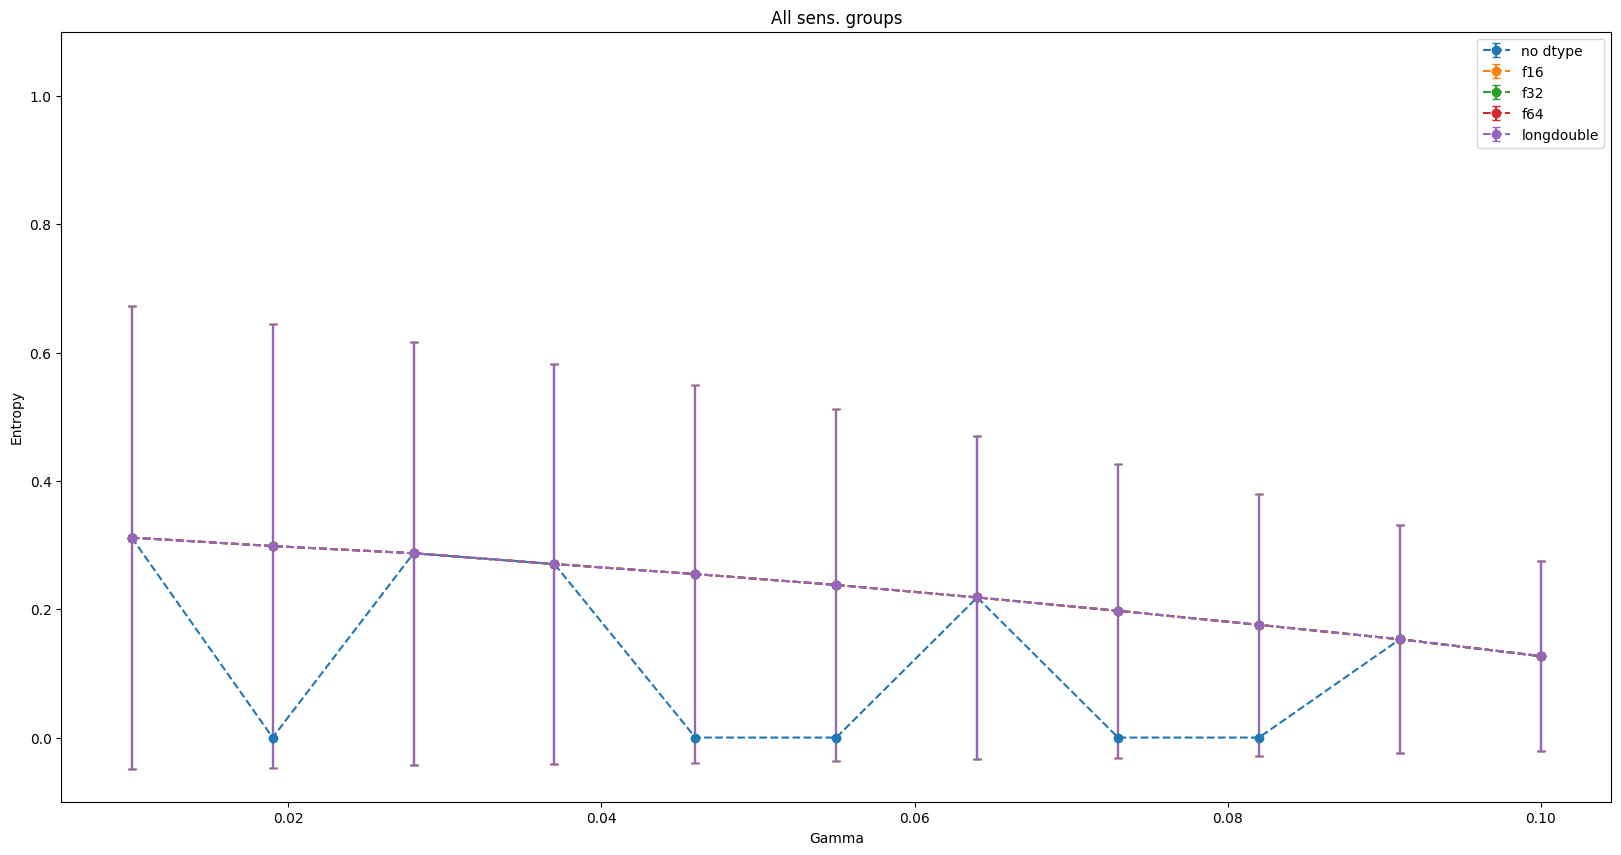

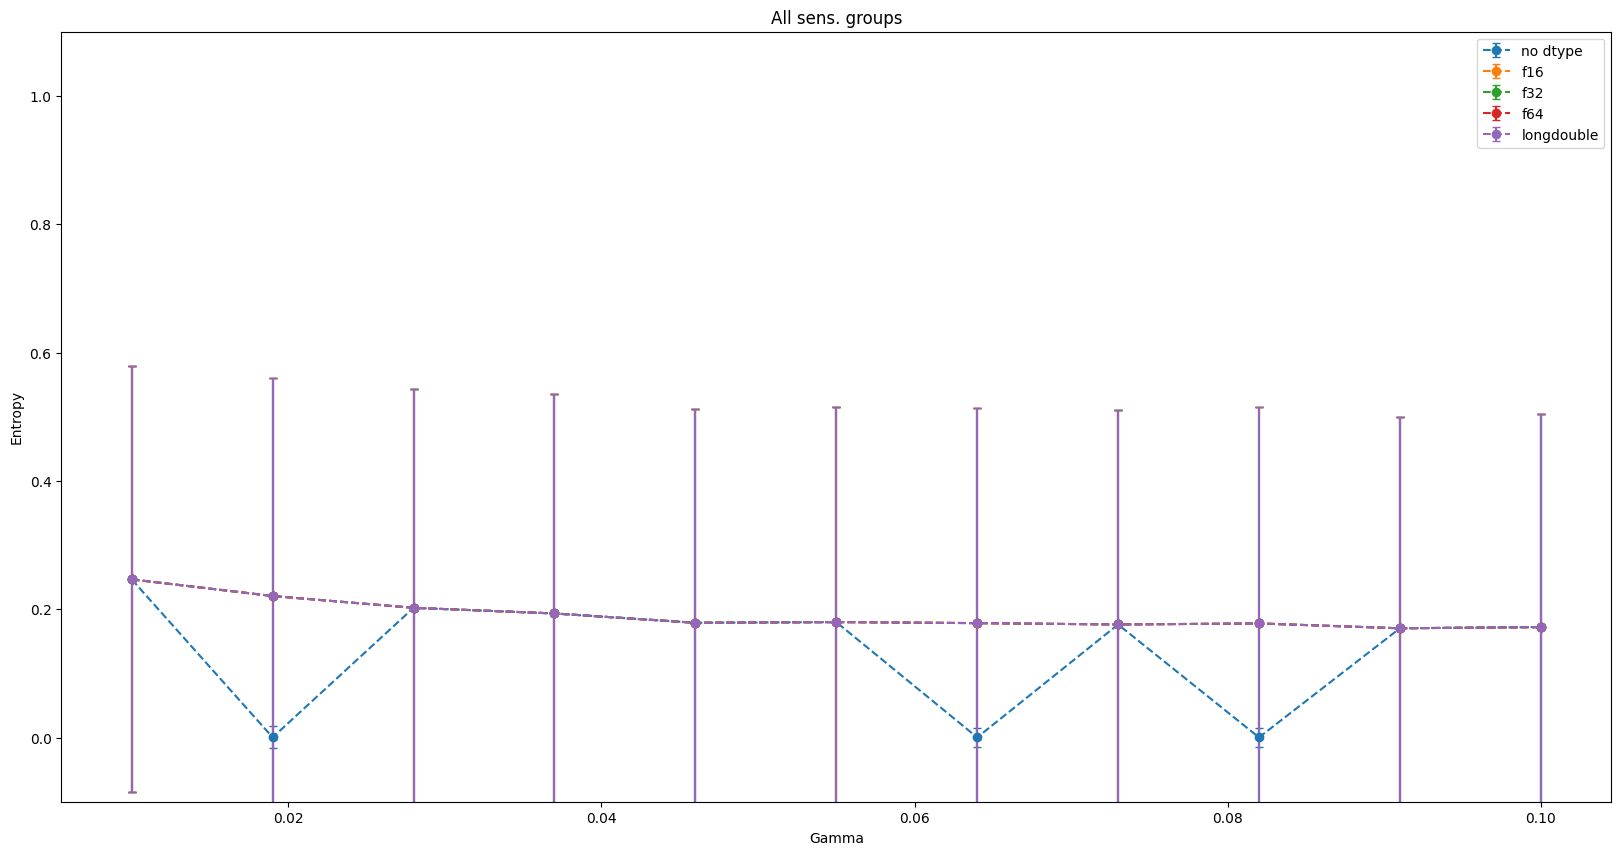

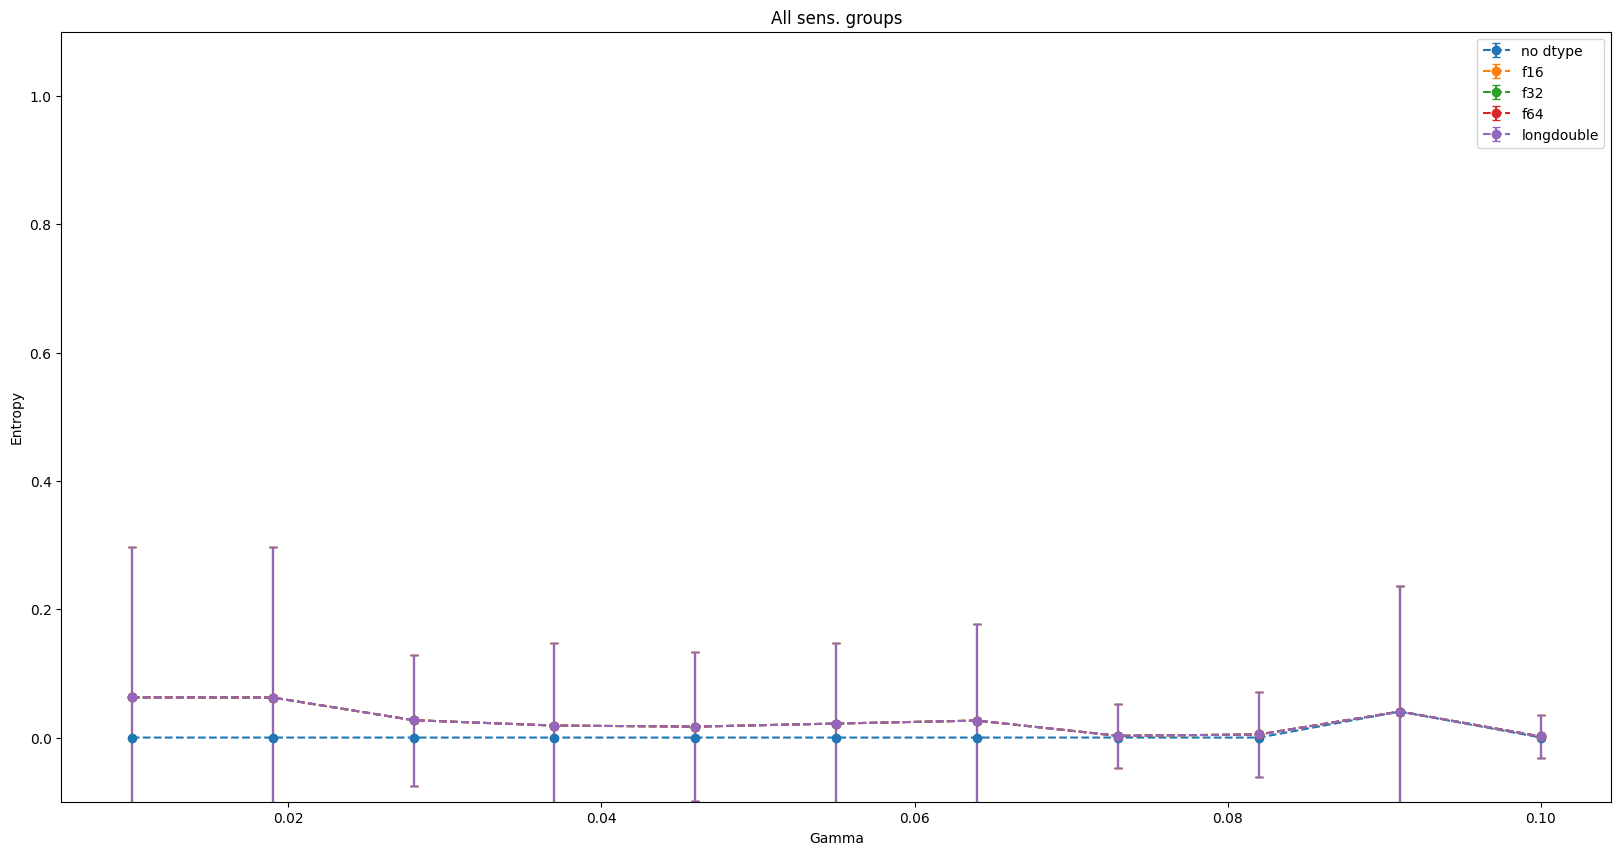

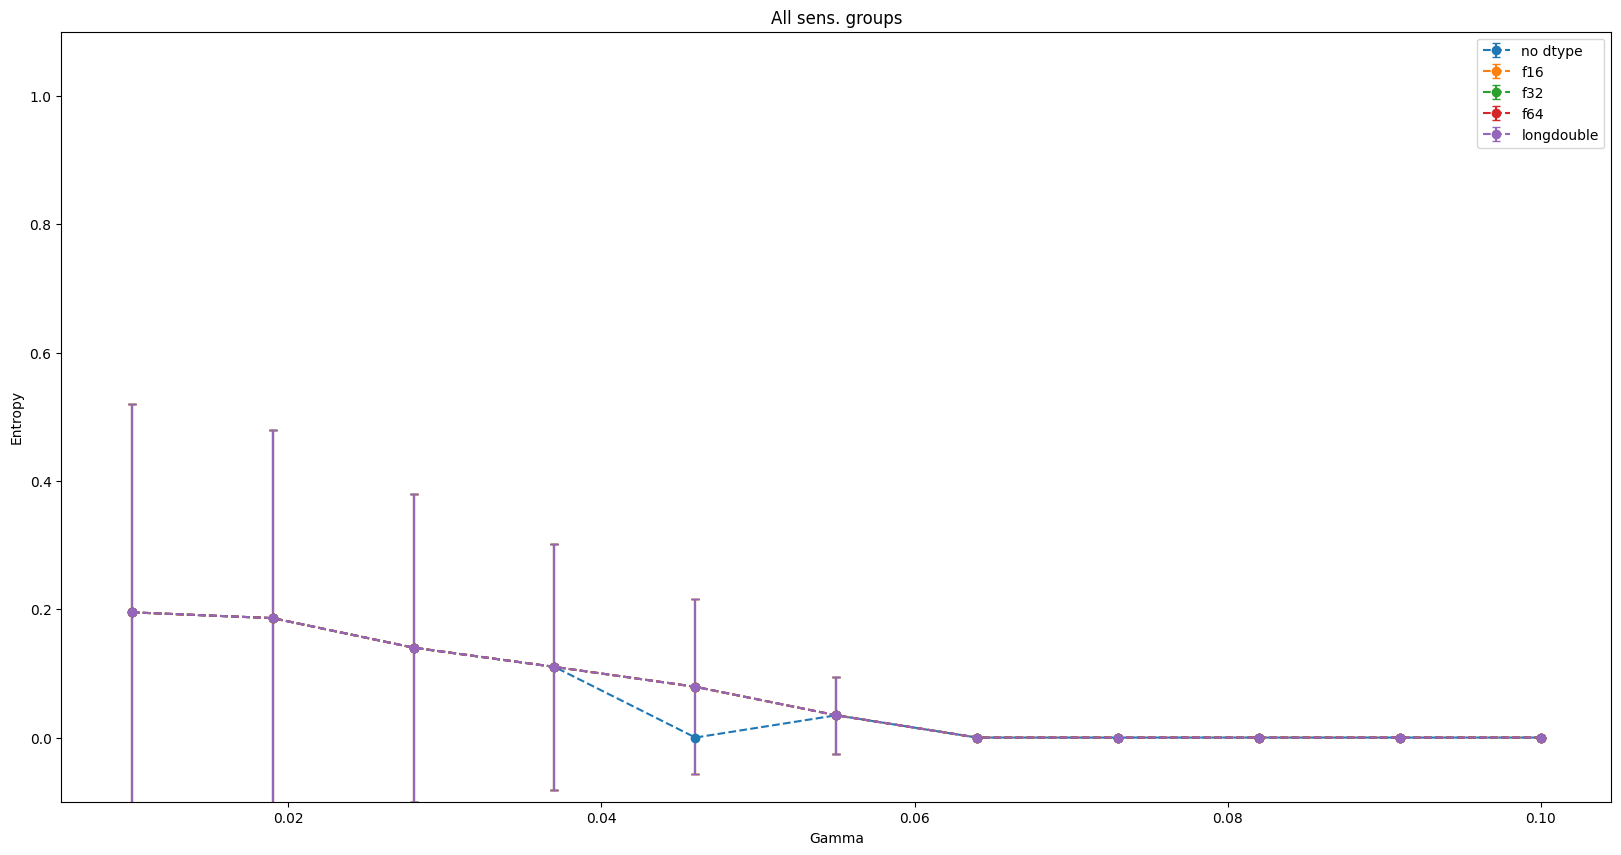

In [20]:
plot_avg_entropy_expgrad("ExpGrad","adult","../results/results_16-12-2025_without_second_vectorize_call/vectorize_experimentadult_ExpGrad_16-12-2025_15-35-50",".")
plot_avg_entropy_expgrad("ExpGrad","banks","../results/results_16-12-2025_without_second_vectorize_call/vectorize_experimentbanks_ExpGrad_16-12-2025_14-18-17",".")
plot_avg_entropy_expgrad("ExpGrad","compas","../results/results_16-12-2025_without_second_vectorize_call/vectorize_experimentcompas_ExpGrad_16-12-2025_13-32-27",".")
plot_avg_entropy_expgrad("ExpGrad","german","../results/results_16-12-2025_without_second_vectorize_call/vectorize_experimentgerman_ExpGrad_16-12-2025_17-28-52",".")